Decision Tree using sklearn

Classification Accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Regression MSE: 0.169


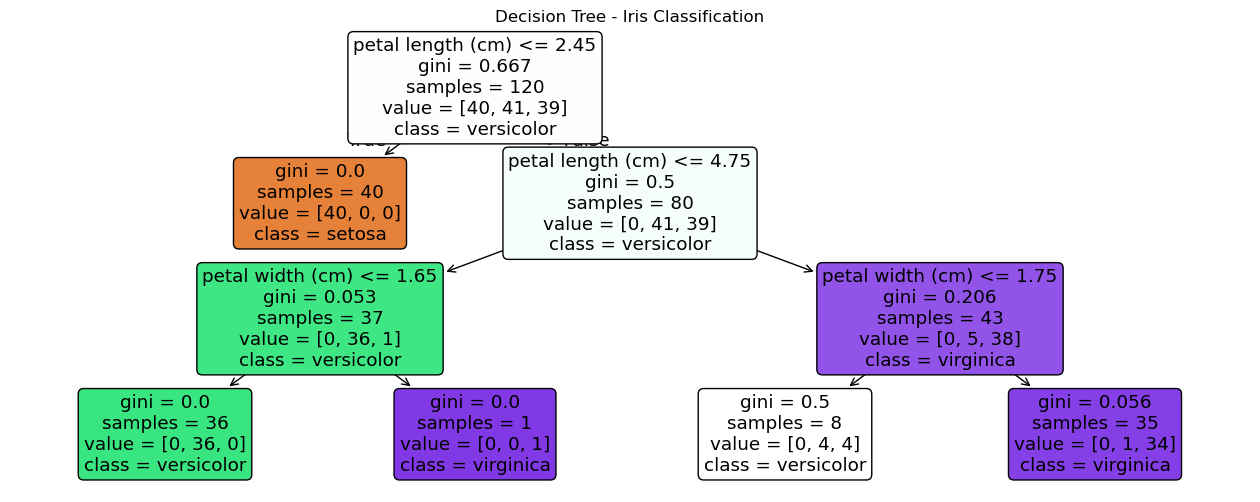

In [5]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error,classification_report
import matplotlib.pyplot as plt
import numpy as np
# --- Classification ---
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
iris.data, iris.target, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print("Classification Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=iris.target_names))
# --- Regression ---
X_r = np.arange(1, 11).reshape(-1, 1)
y_r = np.array([1.5, 3.2, 4.8, 6.1, 7.5, 9.0, 10.2, 11.8, 13.1, 14.5])
reg = DecisionTreeRegressor(max_depth=3, random_state=42)
reg.fit(X_r, y_r)
print("Regression MSE:", round(mean_squared_error(y_r, reg.predict(X_r)), 4))
# --- Plot tree ---
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(clf, feature_names=iris.feature_names,
class_names=iris.target_names, filled=True, rounded=True, ax=ax)
plt.title("Decision Tree - Iris Classification")
# plt.tight_layout()
# plt.savefig("decision_tree.png", dpi=120)
plt.show()

prediction for [5.1,3.5,1.4,0.2] :  [0]


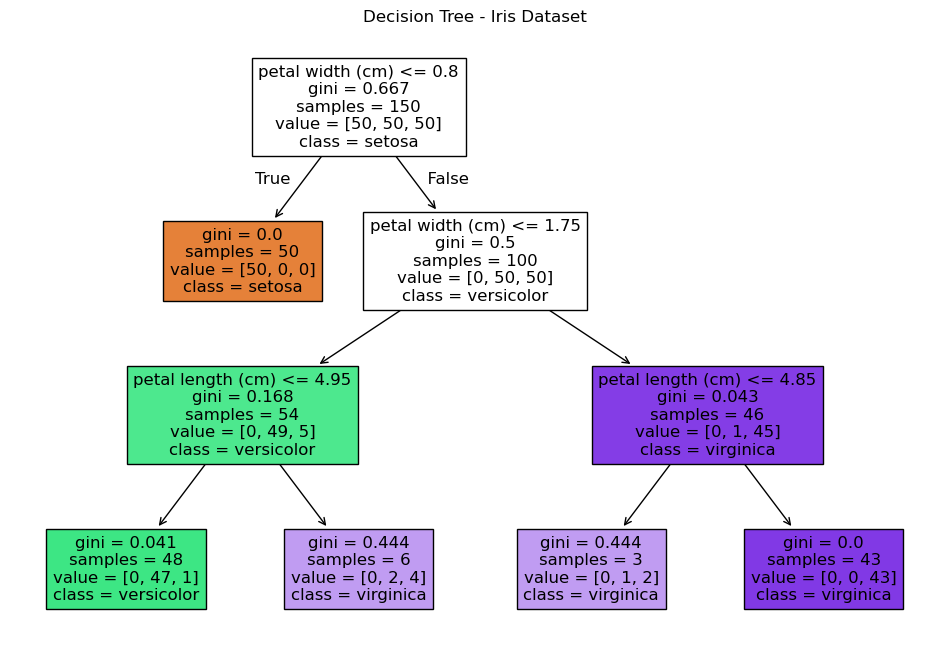

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train model
model = DecisionTreeClassifier(max_depth=3)
model.fit(X, y)

# Prediction
prediction = model.predict([[5.1,3.5,1.4,0.2]])

print("prediction for [5.1,3.5,1.4,0.2] : ",prediction)

# Plot tree
plt.figure(figsize=(12,8))
plot_tree(model,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True)

plt.title("Decision Tree - Iris Dataset")
plt.show()

Construct a Decision tree for a discrete dataset and find entropy for each attribute

In [2]:
import pandas as pd
import numpy as np
from math import log2

# Play Tennis dataset
data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)

# Entropy calculation
def entropy(target):
    values, counts = np.unique(target, return_counts=True)
    entropy_value = 0
    for i in range(len(values)):
        p = counts[i] / sum(counts)
        entropy_value += -p * log2(p)
    return entropy_value

# Information Gain
def information_gain(data, attribute, target="Play"):
    
    total_entropy = entropy(data[target])
    
    values, counts = np.unique(data[attribute], return_counts=True)
    
    weighted_entropy = 0
    for i in range(len(values)):
        subset = data[data[attribute] == values[i]]
        weighted_entropy += (counts[i]/sum(counts)) * entropy(subset[target])
        
    return total_entropy - weighted_entropy


# ID3 Decision Tree
def id3(data, attributes, target="Play"):
    
    # If all target values are same
    if len(np.unique(data[target])) == 1:
        return np.unique(data[target])[0]
    
    # If dataset empty
    if len(data) == 0:
        return None
    
    # If no attributes left
    if len(attributes) == 0:
        return data[target].mode()[0]
    
    # Compute Information Gain for each attribute
    gains = [information_gain(data, attr, target) for attr in attributes]
    
    best_attr = attributes[np.argmax(gains)]
    
    tree = {best_attr:{}}
    
    for value in np.unique(data[best_attr]):
        subset = data[data[best_attr] == value]
        new_attrs = [attr for attr in attributes if attr != best_attr]
        subtree = id3(subset, new_attrs, target)
        tree[best_attr][value] = subtree
        
    return tree


attributes = ['Outlook','Temperature','Humidity','Wind']

tree = id3(df, attributes)

print("Decision Tree:")
print(tree)

Decision Tree:
{'Outlook': {'Overcast': 'Yes', 'Rain': {'Wind': {'Strong': 'No', 'Weak': 'Yes'}}, 'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}}}


In [3]:
import pandas as pd
import numpy as np
from math import log2

# Dataset
data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)

# Entropy function
def entropy(target):
    values, counts = np.unique(target, return_counts=True)
    ent = 0
    for i in range(len(values)):
        p = counts[i] / sum(counts)
        ent += -p * log2(p)
    return ent

# Information Gain
def information_gain(data, attribute, target="Play"):
    total_entropy = entropy(data[target])
    values, counts = np.unique(data[attribute], return_counts=True)
    
    weighted_entropy = 0
    for i in range(len(values)):
        subset = data[data[attribute] == values[i]]
        weighted_entropy += (counts[i]/sum(counts)) * entropy(subset[target])
        
    return total_entropy - weighted_entropy

# Gini impurity
def gini(target):
    values, counts = np.unique(target, return_counts=True)
    g = 1
    for i in range(len(values)):
        p = counts[i] / sum(counts)
        g -= p**2
    return g

# Gini for attribute
def gini_split(data, attribute, target="Play"):
    values, counts = np.unique(data[attribute], return_counts=True)
    
    weighted_gini = 0
    for i in range(len(values)):
        subset = data[data[attribute] == values[i]]
        weighted_gini += (counts[i]/sum(counts)) * gini(subset[target])
        
    return weighted_gini

attributes = ['Outlook','Temperature','Humidity','Wind']

print("Dataset Entropy:", entropy(df["Play"]))

for attr in attributes:
    print("Information Gain for", attr, ":", information_gain(df, attr))

print("\nGini Impurity of dataset:", gini(df["Play"]))

for attr in attributes:
    print("Gini for", attr, ":", gini_split(df, attr))

Dataset Entropy: 0.9402859586706311
Information Gain for Outlook : 0.24674981977443933
Information Gain for Temperature : 0.02922256565895487
Information Gain for Humidity : 0.15183550136234159
Information Gain for Wind : 0.04812703040826949

Gini Impurity of dataset: 0.4591836734693877
Gini for Outlook : 0.34285714285714286
Gini for Temperature : 0.44047619047619047
Gini for Humidity : 0.3673469387755103
Gini for Wind : 0.42857142857142855


In [1]:
import pandas as pd
import numpy as np
from math import log2

# Dataset
df = pd.DataFrame({
 'Outlook':['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
 'Temperature':['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
 'Humidity':['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
 'Wind':['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
 'Play':['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
})

# Entropy
def entropy(y):
    p = y.value_counts(normalize=True)
    return -sum(p * np.log2(p))

# Information Gain
def info_gain(df, attr):
    total = entropy(df['Play'])
    weighted = sum((len(df[df[attr]==v])/len(df)) * 
                   entropy(df[df[attr]==v]['Play']) 
                   for v in df[attr].unique())
    return total - weighted

# Gini
def gini(y):
    p = y.value_counts(normalize=True)
    return 1 - sum(p**2)

# Gini Split
def gini_split(df, attr):
    return sum((len(df[df[attr]==v])/len(df)) * 
               gini(df[df[attr]==v]['Play']) 
               for v in df[attr].unique())

# Output
print("Entropy:", entropy(df['Play']))
for a in ['Outlook','Temperature','Humidity','Wind']:
    print(a, "IG:", info_gain(df,a))

print("\nGini:", gini(df['Play']))
for a in ['Outlook','Temperature','Humidity','Wind']:
    print(a, "Gini:", gini_split(df,a))

Entropy: 0.9402859586706311
Outlook IG: 0.24674981977443933
Temperature IG: 0.02922256565895487
Humidity IG: 0.15183550136234159
Wind IG: 0.04812703040826949

Gini: 0.4591836734693877
Outlook Gini: 0.34285714285714286
Temperature Gini: 0.44047619047619047
Humidity Gini: 0.3673469387755103
Wind Gini: 0.42857142857142855
